# **LABORATORIO #2**
## **Importamos librerias**

In [91]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline

## **Codigo para importar data set del DRIVE**

In [92]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# **Regresion lineal con multibles variables**

## **Descripcion del data set**
El dataset “World Energy Consumption” recopila datos históricos y recientes sobre el consumo y la producción de energía en diferentes países del mundo. Incluye información económica, demográfica y ambiental, como población, PIB, consumo de combustibles fósiles y renovables, generación eléctrica y emisiones de CO₂. Su propósito es analizar la evolución del uso energético global y las relaciones entre desarrollo económico, consumo de energía y sostenibilidad, siendo ideal para aplicar modelos de regresión y predicción en estudios de eficiencia energética.

In [93]:
df = pd.read_csv('/content/gdrive/MyDrive/laboratorios/World Energy Consumption.csv')



# Rellenar valores faltantes

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


# Seleccionar variables

# Variable objetivo
y = df['energy_per_capita'].values

# Variables independientes (todas excepto la de salida)
# Seleccionar solo 10 columnas relevantes
X = df[['year',
        'population',
        'gdp',
        'coal_consumption',
        'oil_consumption',
        'gas_consumption',
        'renewables_consumption',
        'electricity_generation',
        'primary_energy_consumption',
        'greenhouse_gas_emissions']]



# Eliminamos posibles columnas no numéricas (país, etc.)
# para que no generen errores en cálculos posteriores


# Dividir los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertir explícitamente a NumPy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)


# Mostrar tamaños

print("Tamaño total de datos:", len(y))
print("Entrenamiento:", len(y_train))
print("Prueba:", len(y_test))
print()



Tamaño total de datos: 22012
Entrenamiento: 17609
Prueba: 4403



**featureNormalize** es una herramienta que estandariza tu matriz de datos. Convierte tus datos en una versión "limpia" donde cada columna queda centrada en cero y ajustada a una escala de uno (desviación estándar). Además de entregar los datos normalizados, también devuelve los valores (media y desviación) usados en el proceso, permitiendo replicar la estandarización más adelante.

In [94]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [95]:
# Normalizar datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)
# Normalizar datos de prueba con la misma media y desviación
X_test_norm = (X_test - mu) / sigma  # Para test
# Mostrar medias y desviaciones calculadas
print("Media calculada (mu):")
print(mu)
print("\nDesviación estándar calculada (sigma):")
print(sigma)

print("\nPrimeras 5 filas de X normalizado:")
print(X_train_norm[:5, :])


Media calculada (mu):
[1.97429968e+03 8.83225710e+07 2.05796756e+11 5.23217006e+02 8.03168597e+02 4.46244263e+02 1.77967265e+02 2.62829680e+02 2.62415472e+03 7.10170203e+01]

Desviación estándar calculada (sigma):
[3.50151421e+01 4.24738285e+08 1.85695799e+12 2.78683701e+03 3.28456946e+03 1.92460202e+03 8.45363657e+02 1.49093547e+03 1.14755853e+04 5.91186894e+02]

Primeras 5 filas de X normalizado:
[[-0.75109438 -0.19148504 -0.08838253 -0.162819   -0.17731992 -0.16760674 -0.15709365 -0.1621349  -0.22005276 -0.11512776]
 [ 0.27703225 -0.19148504 -0.08838253 -0.162819   -0.17731992 -0.16760674 -0.15709365 -0.1621349  -0.08316088 -0.11512776]
 [-1.32227584 -0.20203851 -0.08838253 -0.162819   -0.17731992 -0.16760674 -0.15709365 -0.1621349  -0.22005276 -0.11512776]
 [ 0.79109557  1.50586518 -0.08838253  1.80189906  2.96749529  4.68785424  2.51163948  2.78482228  2.50138076  2.72460874]
 [-1.77922101 -0.01491285 -0.08838253 -0.162819   -0.17731992 -0.16760674 -0.15709365 -0.1621349  -0.22005

Despues se está añadiendo una columna de unos al inicio de los datos normalizados para representar el término independiente (bias) en la regresión y luego mostrando las primeras filas con formato numérico detallado.

In [96]:
# Agregamos la columna de unos al inicio
m = X_train_norm.shape[0]
X_train_bias = np.concatenate([np.ones((m, 1)), X_train_norm], axis=1)

import numpy as np

# Configurar numpy para mostrar toda la precisión y notación científica
np.set_printoptions(precision=8, suppress=False, linewidth=200)

# Imprimir estilo tabla, cada fila en una línea
print(np.array2string(X_train_bias[:15], formatter={'float_kind':lambda x: f"{x: .8e}"}))


[[ 1.00000000e+00 -7.51094377e-01 -1.91485041e-01 -8.83825308e-02 -1.62818996e-01 -1.77319921e-01 -1.67606736e-01 -1.57093654e-01 -1.62134904e-01 -2.20052760e-01 -1.15127756e-01]
 [ 1.00000000e+00  2.77032253e-01 -1.91485041e-01 -8.83825308e-02 -1.62818996e-01 -1.77319921e-01 -1.67606736e-01 -1.57093654e-01 -1.62134904e-01 -8.31608756e-02 -1.15127756e-01]
 [ 1.00000000e+00 -1.32227584e+00 -2.02038512e-01 -8.83825308e-02 -1.62818996e-01 -1.77319921e-01 -1.67606736e-01 -1.57093654e-01 -1.62134904e-01 -2.20052760e-01 -1.15127756e-01]
 [ 1.00000000e+00  7.91095568e-01  1.50586518e+00 -8.83825308e-02  1.80189906e+00  2.96749529e+00  4.68785424e+00  2.51163948e+00  2.78482228e+00  2.50138076e+00  2.72460874e+00]
 [ 1.00000000e+00 -1.77922101e+00 -1.49128517e-02 -8.83825308e-02 -1.62818996e-01 -1.77319921e-01 -1.67606736e-01 -1.57093654e-01 -1.62134904e-01 -2.20052760e-01 -1.15127756e-01]
 [ 1.00000000e+00 -1.52218935e+00 -2.05717194e-01 -8.83825308e-02 -1.62818996e-01 -1.77319921e-01 -1.6760

# **Descenso por la gradiente**
La función computeCostMulti se encarga de medir qué tan lejos están las predicciones del modelo respecto a los valores reales. Toma como entrada la matriz de datos X, las salidas reales y y los parámetros theta. Calcula el número total de ejemplos, obtiene las predicciones con np.dot(X, theta), halla la diferencia con y, eleva esos errores al cuadrado, los promedia dividiéndolos entre 2m y devuelve J, que representa el costo o error medio cuadrático del modelo.

In [97]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

La función **gradientDescentMulti** realiza el ajuste de los parámetros del modelo usando el método de descenso de gradiente para varias variables. Recibe los datos X, los valores reales y, los parámetros iniciales theta, la tasa de aprendizaje y la cantidad de iteraciones. En cada paso modifica theta para reducir el error y almacena el valor del costo en J_history, devolviendo al final los parámetros optimizados y el registro de cómo fue disminuyendo el costo.

In [98]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]                                                  # Número de ejemplos
    theta = theta.copy()                                            # Copia de theta para no alterar el original
    J_history = []                                                  # Lista para guardar el costo en cada iteración

    for i in range(num_iters):
                                                                    # Actualiza los parámetros reduciendo el error gradualmente
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
                                                                    # Guarda el costo actual para ver cómo disminuye
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history                                          # Retorna parámetros ajustados y la evolución del costo


En este bloque se establece la tasa de aprendizaje y la cantidad de iteraciones, se inicializan los parámetros theta, se entrena el modelo mediante gradientDescentMulti, luego se grafica cómo disminuye el costo durante el entrenamiento y finalmente se crea y normaliza un ejemplo (X_array) para realizar una predicción usando el modelo ya ajustado.

In [99]:
print(X_train.shape[1])
print(X.columns)


10
Index(['year', 'population', 'gdp', 'coal_consumption', 'oil_consumption',
       'gas_consumption', 'renewables_consumption', 'electricity_generation',
       'primary_energy_consumption', 'greenhouse_gas_emissions'],
      dtype='object')


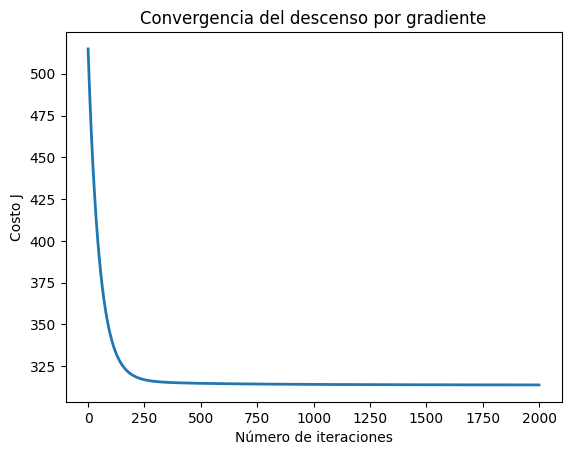

Theta calculado por el descenso de gradiente:
[19.52768056  4.06238283 -2.76005588  1.35861671 -1.38169031  3.17911852  3.94117638 -0.80931996 -2.99681961 -1.35116497  1.6877872 ]
Consumo energético per cápita estimado: -4363117325465.73 kWh/persona


In [100]:


# Escalar el valor objetivo (opcional, para estabilidad numérica)
y_scaled = y_train / 1000                                # dividir entre 1000 para trabajar con valores más pequeños

# Definir tasa de aprendizaje y número de iteraciones
alpha = 0.01
num_iters = 2000

# Inicializar parámetros theta en ceros (uno por cada columna de X)
theta = np.zeros(X_train_bias.shape[1])

# Entrenar modelo usando descenso por gradiente
theta, J_history = gradientDescentMulti(X_train_bias, y_scaled, theta, alpha, num_iters)

# Graficar convergencia del costo
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del descenso por gradiente')
plt.show()

# Mostrar parámetros calculados
print('Theta calculado por el descenso de gradiente:')
print(theta)

# Predicción de consumo energético (nuevo ejemplo)
# Creamos un ejemplo con valores de entrada representativos (1 = bias)
X_array = np.array([1, 2015, 5e8, 3e12, 1e9, 8e8, 5e8, 2e8, 3e12, 4e11, 6e11], dtype=float)


# Normalizar (excepto el primer valor que es el bias)
X_array[1:] = (X_array[1:] - mu) / sigma
X_array = np.nan_to_num(X_array)  # reemplazar posibles NaN

# Calcular predicción del consumo energético per cápita
energy_pred = np.dot(X_array, theta) * 1000   # reconvertir a la escala original

print('Consumo energético per cápita estimado: {:.2f} kWh/persona'.format(energy_pred))


## **Ecuacion de la Normal**

In [101]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

En esta parte se agregan los datos ajustados con una columna de unos para incluir el término independiente, luego se aplica la función normalEqn para obtener los parámetros óptimos del modelo mediante el método analítico de la ecuación normal, y al final se muestra el vector θ calculado, que representa la mejor solución encontrada sin usar iteraciones.

In [102]:
import numpy as np

# Mostrar más precisión y usar notación científica
np.set_printoptions(precision=8, suppress=False, linewidth=200)

# Agregar columna de unos para el término independiente (bias)
X_train_original = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)

# Calcular los parámetros óptimos (theta) mediante la ecuación normal
theta = normalEqn(X_train_original, y_train)

# Mostrar los parámetros obtenidos
print("Theta calculado a partir de la ecuación normal para el modelo de consumo energético:")
print(np.array2string(theta, formatter={'float_kind':lambda x: f"{x: .8e}"}))


Theta calculado a partir de la ecuación normal para el modelo de consumo energético:
[-2.09908225e+05  1.16115129e+02 -6.99341644e-06  7.02324595e-10 -3.39421488e-01  8.24107435e-01  2.76604879e+00 -1.93119459e+00 -2.48516776e+00 -1.22023881e-01  3.68109149e+00]


In [103]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Normalizar los datos de prueba con las medias y desviaciones del entrenamiento
X_test_norm = (X_test - mu) / sigma

# Agregar columna de unos (bias) para el conjunto de prueba normalizado
X_test_bias = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

# Predecir consumo energético per cápita con theta obtenido por gradiente descendente
y_pred_gd = np.dot(X_test_bias, theta) * 1000   # recordando que y se escaló dividiéndolo por 1000

# Calcular theta mediante la ecuación normal usando los datos originales (sin normalizar)
X_train_bias = np.concatenate([np.ones((X_train.shape[0], 1)), X_train], axis=1)
theta_normal = normalEqn(X_train_bias, y_train)

# Predecir consumo energético con la ecuación normal
X_test_original = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)
y_pred_ne = np.dot(X_test_original, theta_normal)

# Calcular error cuadrático medio (RMSE) para ambos métodos
rmse_gd = np.sqrt(mean_squared_error(y_test, y_pred_gd))
rmse_ne = np.sqrt(mean_squared_error(y_test, y_pred_ne))

print(f"RMSE Gradiente Descendente: {rmse_gd:,.2f} kWh/persona")
print(f"RMSE Ecuación Normal: {rmse_ne:,.2f} kWh/persona")

# Mostrar primeras 5 comparaciones entre predicción y valor real
print("\nPrimeras 5 predicciones vs valor real:")
for i in range(5):
    print(f"Gradiente: {y_pred_gd[i]:,.2f} | Ecuación Normal: {y_pred_ne[i]:,.2f} | Real: {y_test[i]:,.2f}")


RMSE Gradiente Descendente: 209,928,819.74 kWh/persona
RMSE Ecuación Normal: 25,958.10 kWh/persona

Primeras 5 predicciones vs valor real:
Gradiente: -210,085,219.80 | Ecuación Normal: 13,497.46 | Real: 13,597.99
Gradiente: -209,862,041.32 | Ecuación Normal: 5,294.77 | Real: 18,068.98
Gradiente: -209,756,904.08 | Ecuación Normal: 25,084.03 | Real: 0.00
Gradiente: -209,770,124.86 | Ecuación Normal: 24,561.83 | Real: 8,800.30
Gradiente: -210,085,219.80 | Ecuación Normal: 13,488.88 | Real: 13,597.99


## **Descenso por la Gradiente polinomial**

In [104]:
df = pd.read_csv('/content/gdrive/MyDrive/laboratorios/World Energy Consumption.csv')



# Rellenar valores faltantes

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


# Seleccionar variables

# Variable objetivo
y = df['energy_per_capita'].values

# Variables independientes (todas excepto la de salida)
# Seleccionar solo 10 columnas relevantes
X = df[['year',
        'population',
        'gdp',
        'coal_consumption',
        'oil_consumption',
        'gas_consumption',
        'renewables_consumption',
        'electricity_generation',
        'primary_energy_consumption',
        'greenhouse_gas_emissions']]



# Eliminamos posibles columnas no numéricas (país, etc.)
# para que no generen errores en cálculos posteriores


# Dividir los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertir explícitamente a NumPy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)


# Mostrar tamaños

print("Tamaño total de datos:", len(y))
print("Entrenamiento:", len(y_train))
print("Prueba:", len(y_test))
print()



Tamaño total de datos: 22012
Entrenamiento: 17609
Prueba: 4403



In [105]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

In [106]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

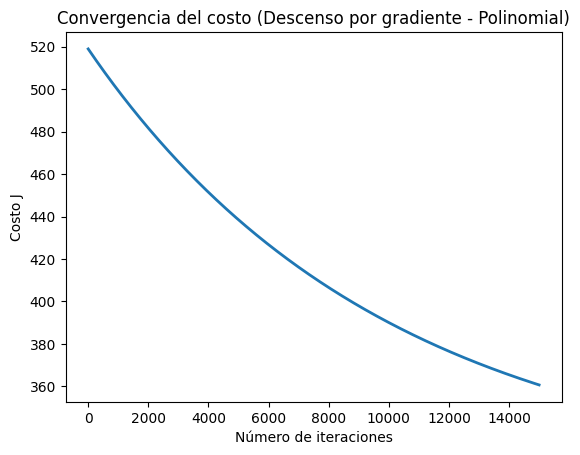

Theta polinomial calculado:
[10.30363039  2.01478177 -0.54614224  0.83750281  0.04334418  0.61755127  0.73380273  0.36569933  0.08313861  0.10812289  0.19243117 -0.56265962 -0.42303201 -0.19059244 -0.34048858  0.07180658
  0.03469947 -0.14471241 -0.24641188 -0.28272319 -0.13581636]
Consumo energético per cápita estimado (modelo polinómico): -25022260812714865989502631936.00 kWh/persona


In [113]:
# Regresión Polinómica Multivariable (World Energy Consumption)

from matplotlib import pyplot as plt
import numpy as np

# Crear términos polinómicos (x²)
X_poly = np.concatenate([X_train_norm, X_train_norm**2], axis=1)

# Normalizar los nuevos términos polinómicos
mu_poly = np.mean(X_poly, axis=0)
sigma_poly = np.std(X_poly, axis=0)
X_poly_norm = (X_poly - mu_poly) / sigma_poly

# Agregar columna de unos para el bias
m_poly = X_poly_norm.shape[0]
X_poly_bias = np.concatenate([np.ones((m_poly, 1)), X_poly_norm], axis=1)


# Definir tasa de aprendizaje y número de iteraciones
alpha = 0.00005
num_iters = 15000
# Inicializar parámetros theta
theta_poly = np.zeros(X_poly_bias.shape[1])

# Entrenar modelo con descenso por gradiente
theta_poly, J_history = gradientDescentMulti(X_poly_bias, y_scaled, theta_poly, alpha, num_iters)


# Graficar la convergencia del costo

plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del costo (Descenso por gradiente - Polinomial)')
plt.show()

# Mostrar los parámetros calculados
print('Theta polinomial calculado:')
print(theta_poly)


# Predicción con el modelo polinómico


# Crear ejemplo representativo (mismo orden que tus variables seleccionadas)
X_array = np.array([2020, 7.8e9, 8e13, 3e9, 4e9, 2e9, 1e9, 5e12, 1.5e12, 1.2e12], dtype=float)

# Crear variables polinómicas (x²)
X_array_poly = np.concatenate([X_array, X_array**2])

# Normalizar usando medias y desviaciones del conjunto polinómico
mu_poly = np.mean(X_poly, axis=0)
sigma_poly = np.std(X_poly, axis=0)
X_array_poly_norm = (X_array_poly - mu_poly) / sigma_poly
X_array_poly_norm = np.nan_to_num(X_array_poly_norm)

# Agregar 1 para el bias
X_array_poly_bias = np.concatenate([[1], X_array_poly_norm])

# Calcular predicción escalada y reconvertir
energy_scaled = np.dot(X_array_poly_bias, theta_poly)
energy_pred = energy_scaled * 1000   # volver a la escala original

print('Consumo energético per cápita estimado (modelo polinómico): {:.2f} kWh/persona'.format(energy_pred))


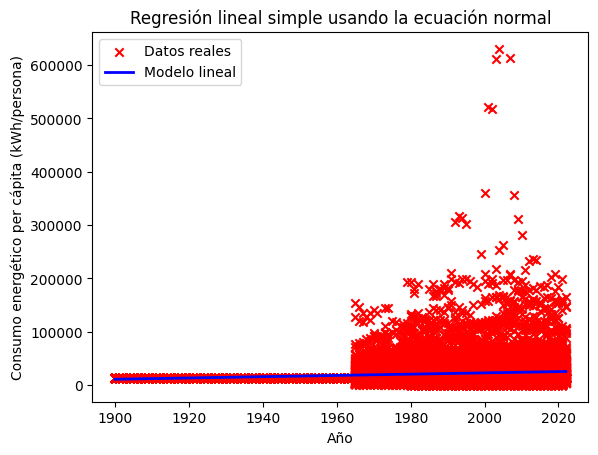

Theta calculado (intercepto y pendiente):
[-2.16724991e+05  1.19664038e+02]


In [112]:
#Regresión Lineal Simple (World Energy Consumption)

import matplotlib.pyplot as plt
import numpy as np

# Convertir a NumPy por seguridad (si X_train viene como DataFrame)
X_array_train = np.array(X_train)
y_array_train = np.array(y_train)

# Usar una sola característica: columna 0 = 'year'
X_simple = np.column_stack([np.ones(X_array_train.shape[0]), X_array_train[:, 0]])

# Calcular parámetros óptimos con la ecuación normal
theta_simple = normalEqn(X_simple, y_array_train)

# Graficar los datos: año vs consumo energético
plt.scatter(X_array_train[:, 0], y_array_train, color='red', marker='x', label='Datos reales')

# Generar línea de regresión (predicción del modelo)
x_line = np.linspace(X_array_train[:, 0].min(), X_array_train[:, 0].max(), 100)
y_line = theta_simple[0] + theta_simple[1] * x_line

# Mostrar la línea del modelo
plt.plot(x_line, y_line, color='blue', lw=2, label='Modelo lineal')

# Etiquetas y título
plt.xlabel('Año')
plt.ylabel('Consumo energético per cápita (kWh/persona)')
plt.title('Regresión lineal simple usando la ecuación normal')
plt.legend()
plt.show()

# Mostrar parámetros calculados
print("Theta calculado (intercepto y pendiente):")
print(theta_simple)
